In [ ]:
#Importação das bibliotecas exenciais

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import kagglehub
from kagglehub import KaggleDatasetAdapter
import json
import numpy as np
import re

In [ ]:
# Carregar datasets diretamente em DataFrames do pandas através do Kaggle

dataset_perfis = "likithagedipudi/linkedin-compatibility-dataset-50k-profiles"

# Dataframe para perfis do LinkedIn
df_profiles = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_perfis,
    "profiles.csv",
)

# Dataframe para pares de compatibilidade
df_pairs = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_perfis,
    "compatibility_pairs.csv",
)

dataset_influencers = "shreyasajal/linkedin-influencers-data"

# Dataframe para dados de influenciadores do LinkedIn
df_influencers = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_influencers,
    "influencers_data.csv",
)

In [ ]:
# Ver informações dos dataframes
display("Informação de Perfis :")
display(df_profiles.info())
display(df_profiles.describe())
display("================================================================")
display("Informação de Pairs :")
display(df_pairs.info())
display(df_pairs.describe())
display("================================================================")
display("Informação de Influencers :")
display(df_influencers.info())
display(df_influencers.describe())


In [ ]:
# Limpar dataframe de perfis
def parse_json_safely(value):
    if pd.isna(value) or value == "":
        return [] # Return empty list so .apply(len) works later
    if isinstance(value, str):
        try:
            return json.loads(value)
        except (json.JSONDecodeError, TypeError):
            return []
    return value

cols_to_parse = ["skills", "experience", "education", "goals", "needs", "can_offer"]

for col in cols_to_parse:
    if col in df_profiles.columns:
        df_profiles[col] = df_profiles[col].apply(parse_json_safely)

# Criar features de contagem de habilidades, experiência, educação, etc.

df_profiles["num_skills"] = df_profiles["skills"].apply(len)
df_profiles["num_experience"] = df_profiles["experience"].apply(len)
df_profiles["num_education"] = df_profiles["education"].apply(len)
df_profiles["about_length"] = df_profiles["about"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_profiles["headline_length"] = df_profiles["headline"].apply(lambda x: len(x) if isinstance(x, str) else 0)

# Remover perfis duplicados pelo identificador único
df_profiles = df_profiles.drop_duplicates(subset=["profile_id"], keep="first").reset_index(drop=True)


In [ ]:
# Limpar dataframe de pares de compatibilidade

# Apagar coluna de skill_complementarity_score (está sempre 0 → não traz informação)
df_pairs = df_pairs.drop(columns=["skill_complementarity_score"], errors="ignore")

# 2. Garantir integridade: só manter pares onde ambos perfis existem
valid_profile_ids = set(df_profiles["profile_id"])
df_pairs = df_pairs[
    df_pairs["profile_a_id"].isin(valid_profile_ids) & 
    df_pairs["profile_b_id"].isin(valid_profile_ids)
].reset_index(drop=True)

print(f"Linhas após filtro de IDs válidos: {len(df_pairs):,}")


In [ ]:
# =============================================================================
# SCORE DE "DESCOBERTA" DO PERFIL (0 a 100)
# -----------------------------------------------------------------------------
# Objetivo: Criar uma nota comparável à dos posts, indicando quão "descobrível"
# um perfil é no algoritmo do LinkedIn (compatibilidade com outros perfis).
#
# Nota: Usamos apenas normalização min-max simples (sem log ou clipping).
# Motivo: O avg_compatibility_score é uma média agregada de milhares de pares,
# com distribuição suave e sem outliers extremos (range ~19.75 a ~63.98).
# Aplicar log ou clipping aqui seria overkill e distorceria a proporcionalidade real.
# =============================================================================


# Calcular média de compatibility_score por perfil (proxy inicial de discoverability)
avg_compat = df_pairs.groupby('profile_a_id')['compatibility_score'].mean().rename('avg_compatibility_score')

# Merge apenas se a coluna NÃO existir ainda (evita erro ao re-executar)
if 'avg_compatibility_score' not in df_profiles.columns:
    df_profiles = df_profiles.merge(
        avg_compat, 
        left_on='profile_id', 
        right_index=True, 
        how='left'
    )
    print("Coluna 'avg_compatibility_score' adicionada com sucesso.")
else:
    print("Coluna 'avg_compatibility_score' já existe → merge ignorado para evitar duplicação.")

# 5. Tratar valores ausentes (perfis sem pares)
df_profiles['avg_compatibility_score'] = df_profiles['avg_compatibility_score'].fillna(0)

# Só normaliza se a coluna existir (segurança extra)
if 'avg_compatibility_score' in df_profiles.columns:
    min_compat = df_profiles["avg_compatibility_score"].min()
    max_compat = df_profiles["avg_compatibility_score"].max()

    if max_compat > min_compat:
        df_profiles["profile_discoverability_score"] = 100 * (
            (df_profiles["avg_compatibility_score"] - min_compat) / (max_compat - min_compat)
        )
    else:
        df_profiles["profile_discoverability_score"] = 0.0
df_profiles.info()

In [ ]:
# Limpar dataframe de influencers

# Remover colunas que não são relevantes para a análise
# views e votes estão praticamente vazios e connections tem baixa variabilidade
df_influencers = df_influencers.drop(columns=["views", "votes", "connections"], errors="ignore")

# Se já estiver no índice, não tenta set_index de novo
if df_influencers.index.name == "serial_number":
    print("serial_number já é o índice.")
else:
    # Tenta renomear colunas comuns para serial_number 
    rename_map = {
        "Unnamed: 0": "serial_number",
        "unnamed: 0": "serial_number",
        "index": "serial_number",
        "Index": "serial_number",
    }
    df_influencers = df_influencers.rename(columns=rename_map)

    if "serial_number" in df_influencers.columns:
        df_influencers = df_influencers.set_index("serial_number", verify_integrity=False)
        print("serial_number definido como índice.")
    else:
        print("Não foi encontrada coluna para usar como serial_number. Mantendo índice atual.")

# Preencher Dados que estão vazios
df_influencers["location"] = df_influencers["location"].fillna("Unknown")
df_influencers["followers"] = df_influencers["followers"].astype("Int64").fillna(0)
df_influencers["content"] = df_influencers["content"].fillna("Empty Post")
df_influencers["media_type"] = df_influencers["media_type"].fillna("Unknown")

# Conveter time_spent para numérico, tratando erros

def time_spent_to_days(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()

    # Casos rápidos
    if text in {"just now", "now"}:
        return 0

    # Ex.: "1 day ago", "5 months ago", "1 week ago"
    m = re.match(r"^\s*(\d+)\s+([a-z]+)\s+ago\s*$", text)
    if not m:
        return pd.NA

    qty = int(m.group(1))
    unit = m.group(2)

    factors = {
        "minute": 0, "minutes": 0,
        "hour": 0,   "hours": 0,
        "day": 1,    "days": 1,
        "week": 7,   "weeks": 7,
        "month": 30, "months": 30,
        "year": 365, "years": 365,
    }

    if unit not in factors:
        return pd.NA

    return qty * factors[unit]

# Converter a coluna (mantendo inteiro anulável)
df_influencers["time_spent"] = (
    df_influencers["time_spent"]
    .apply(time_spent_to_days)
    .astype("Int64")
    .fillna(0)+1
) 


In [ ]:
# =============================================================================
# SCORE DE "DESCOBERTA" DO POST (0 a 100)
# -----------------------------------------------------------------------------
# Objetivo: Criar uma nota simples para estimar quais posts têm mais "força" 
# para aparecer a mais pessoas no feed do LinkedIn.
#
# Nota importante: Isto NÃO é o algoritmo real do LinkedIn.
# É uma simulação académica, transparente e explicável.
# =============================================================================

# 1) Engagement bruto (pontuação base do post)
# Fórmula: reactions + 5 * comments
# Porque: Comentários indicam interação mais profunda (peso 5 é valor médio comum em análises de redes sociais 2024–2026)
df_influencers["engagement_raw"] = (
    df_influencers["reactions"].fillna(0) +
    5 * df_influencers["comments"].fillna(0)
)

# 2) Engagement por dia (normalização pelo tempo)
# Motivo: Posts antigos acumulam mais interações por terem mais tempo de exposição.
# Sem dividir por tempo, posts antigos parecem artificialmente melhores.
# Usamos time_spent já ajustado (+1) para evitar divisão por zero.
df_influencers["engagement_per_day"] = (
    df_influencers["engagement_raw"] / df_influencers["time_spent"]
)

# 3) Limpeza numérica (higiene de dados)
# Substituímos inf e NaN por 0 para evitar erros em modelos e gráficos.
df_influencers["engagement_per_day"] = (
    df_influencers["engagement_per_day"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .round(2)
)

# 4) Clipping de outliers extremos (winsorização no percentil 99)
# Motivo principal: Os dados de engajamento em redes sociais seguem distribuição power-law:
#   - Muitos posts com 0–50 interações
#   - Poucos posts virais com milhares (ex: max 391k reactions vs mediana 36)
# Sem clipping, 1–2 posts dominam toda a escala e "esmagam" os outros para perto de 0.
# Clipping no p99 mantém a ordem relativa mas reduz influência desproporcional de virais.
p99 = df_influencers["engagement_per_day"].quantile(0.99)
df_influencers["engagement_per_day_clipped"] = df_influencers["engagement_per_day"].clip(upper=p99)

# 5) Compressão logarítmica (log1p)
# Motivo: Mesmo após clipping, a distribuição continua enviesada (skew alto).
# O log "comprime" valores grandes (ex: log(1000) ≈ 6.9 vs log(10) ≈ 2.3) e "abre" os pequenos,
# tornando a escala mais uniforme e adequada para normalização e modelagem posterior.
# log1p(x) = log(1 + x) é estável para zero e evita problemas numéricos.
df_influencers["log_engagement_per_day"] = np.log1p(df_influencers["engagement_per_day_clipped"])

# 6) Normalização min-max para 0–100
# Motivo: Facilita interpretação humana e comparação com o score de perfis.
# Tratamos caso degenerado (max == min) para evitar divisão por zero.
min_log = df_influencers["log_engagement_per_day"].min()
max_log = df_influencers["log_engagement_per_day"].max()

if max_log > min_log:
    df_influencers["post_discoverability_score"] = 100 * (
        (df_influencers["log_engagement_per_day"] - min_log) / (max_log - min_log)
    )
else:
    df_influencers["post_discoverability_score"] = 0.0

df_influencers.info()

=== RESUMO DOS TARGETS DE DISCOVERABILITY ===
       profile_discoverability_score
count                       50000.00
mean                           52.65
std                            24.10
min                             0.00
25%                            29.96
50%                            59.46
75%                            72.00
max                           100.00


       post_discoverability_score
count                     34012.0
mean                        11.32
std                         19.29
min                           0.0
25%                          0.63
50%                          2.61
75%                         12.78
max                         100.0


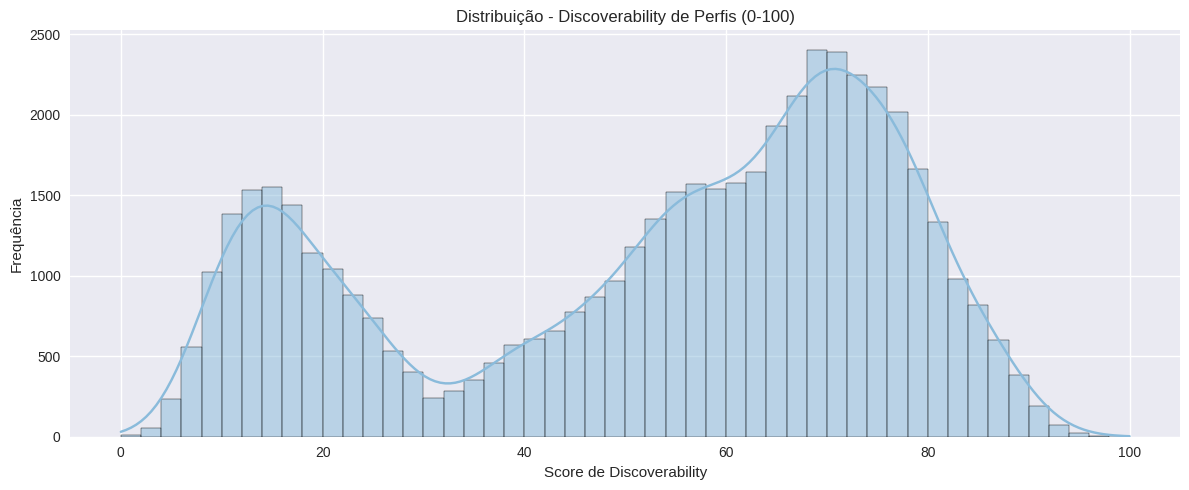

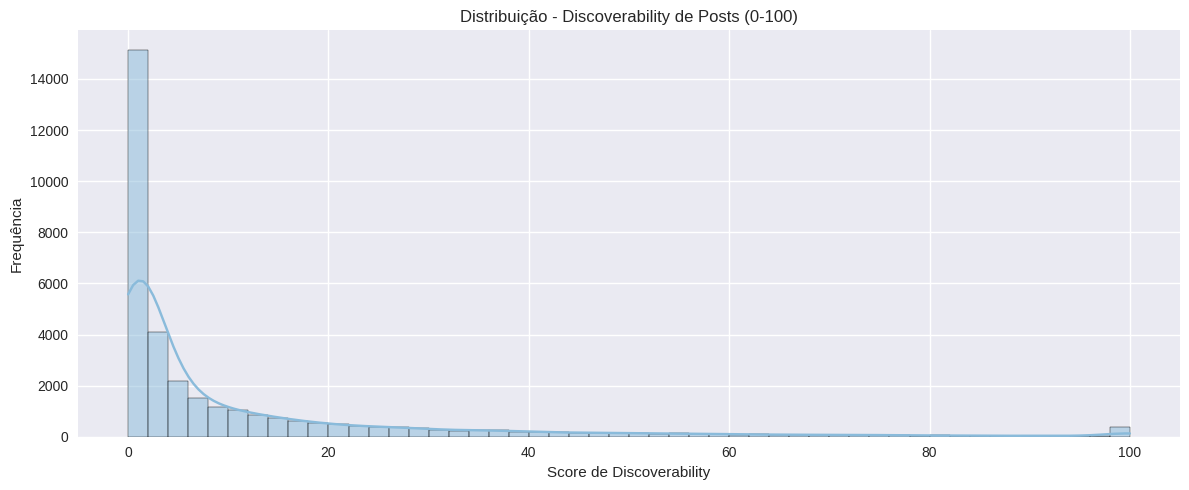

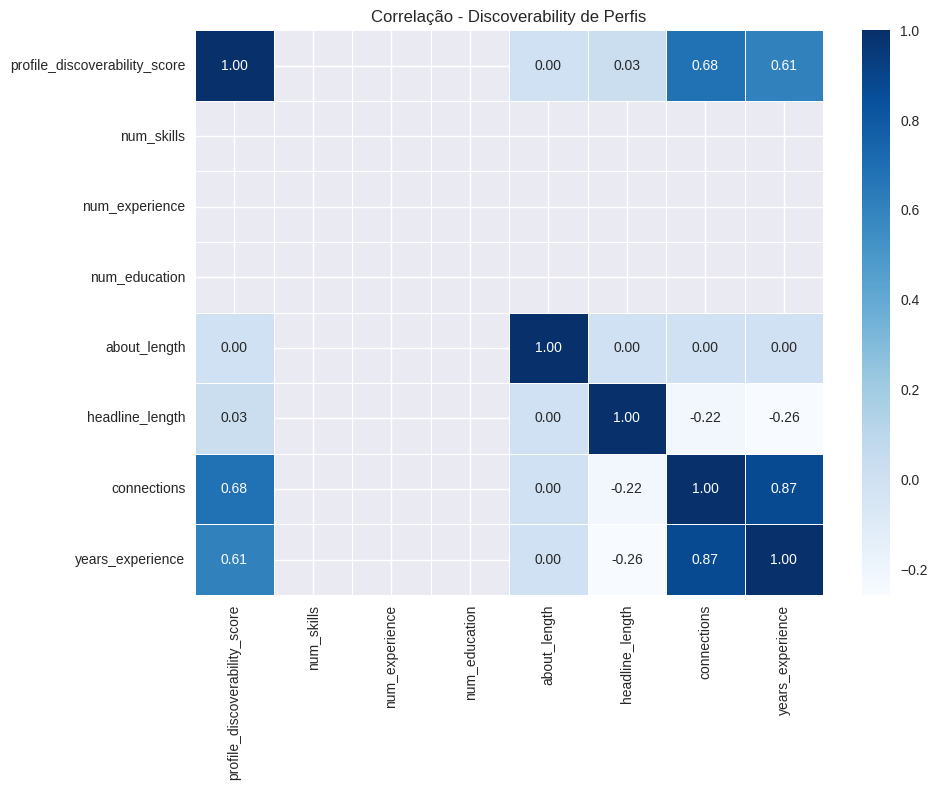

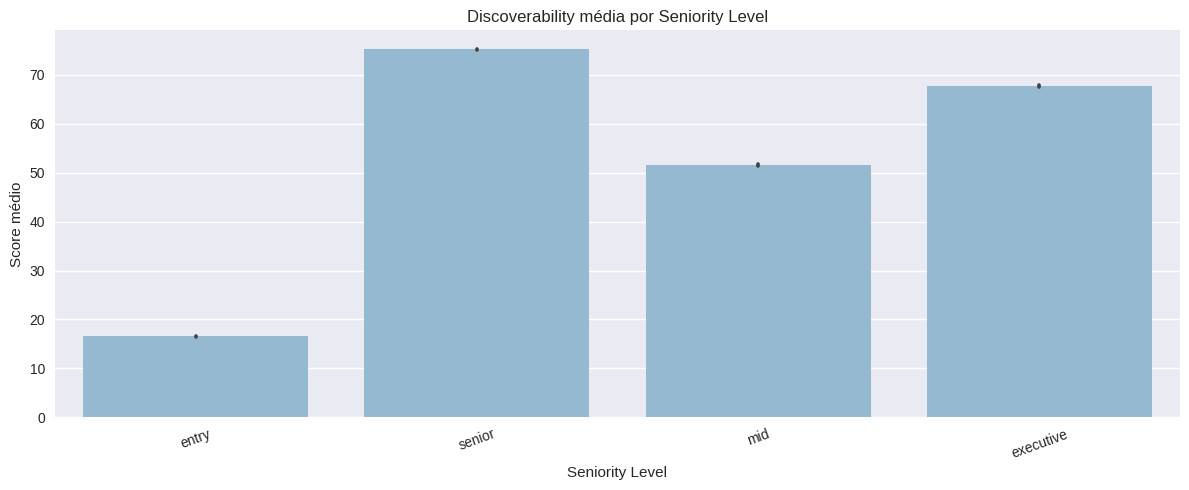

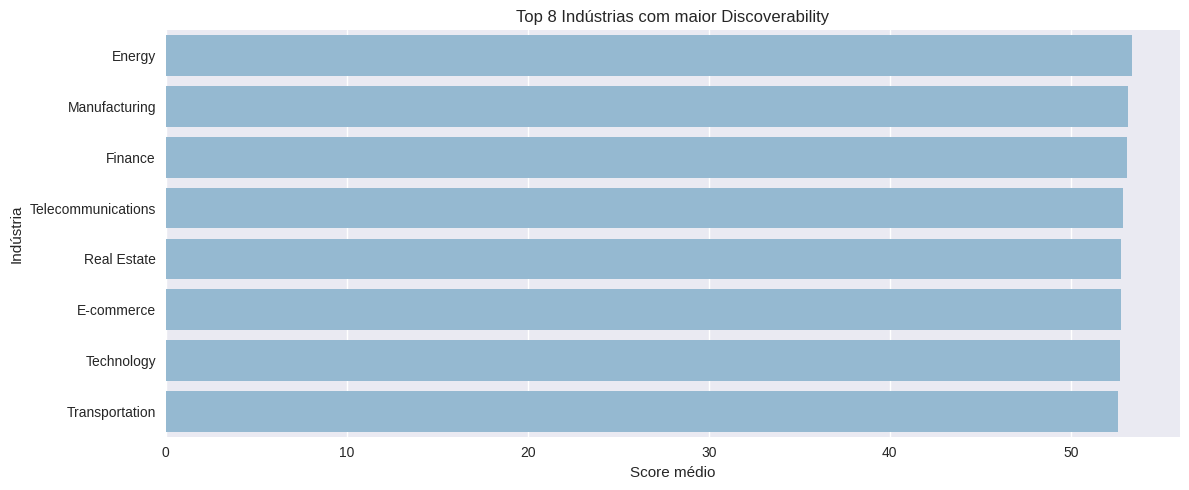

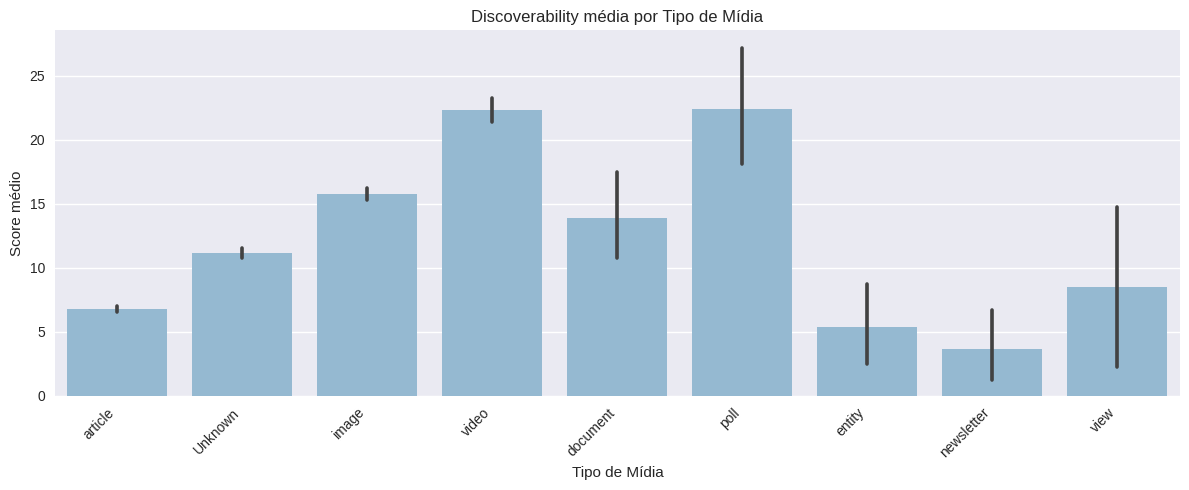

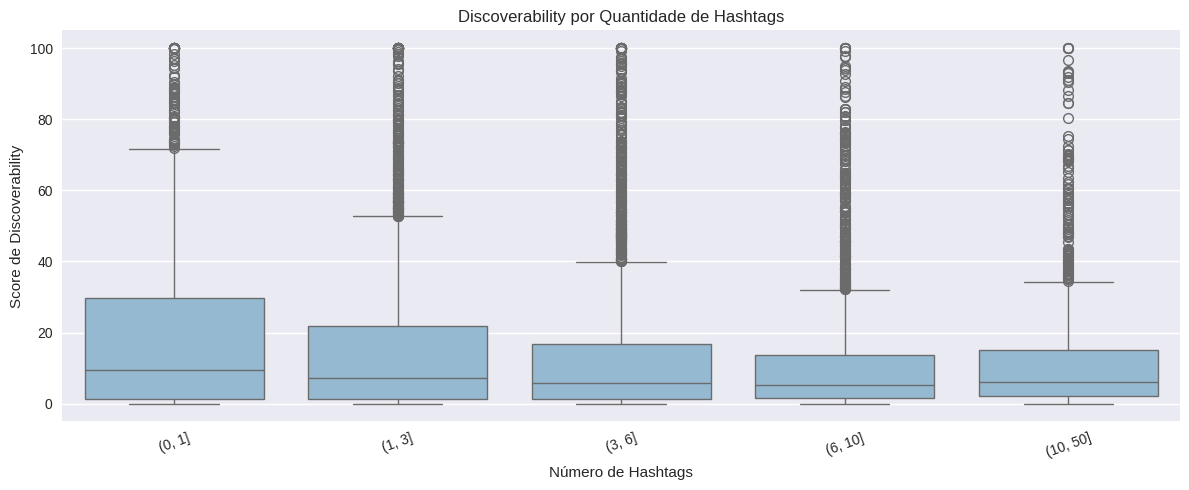

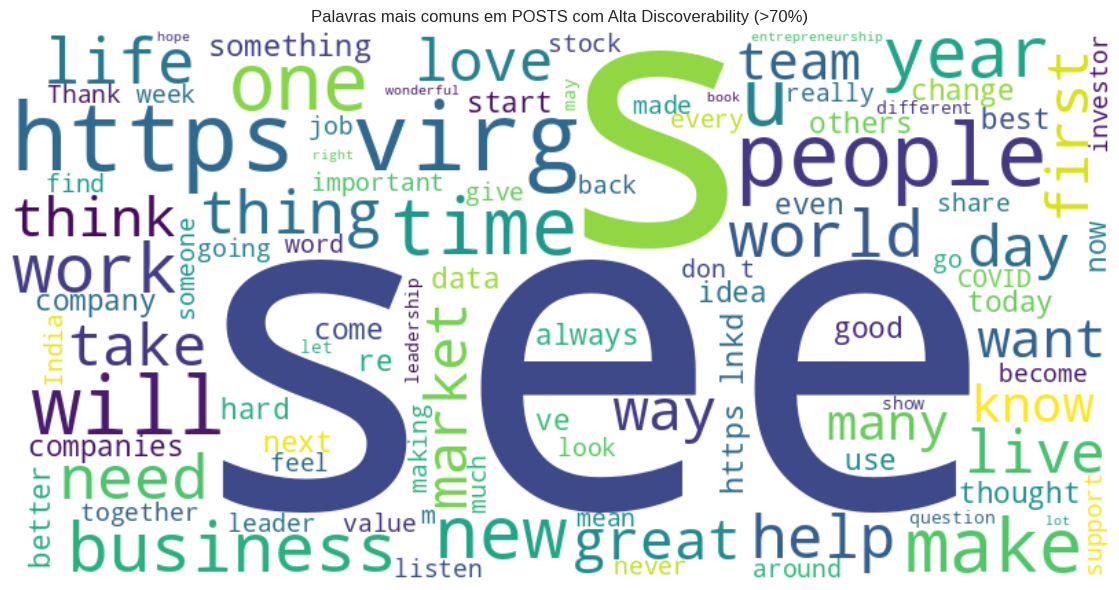

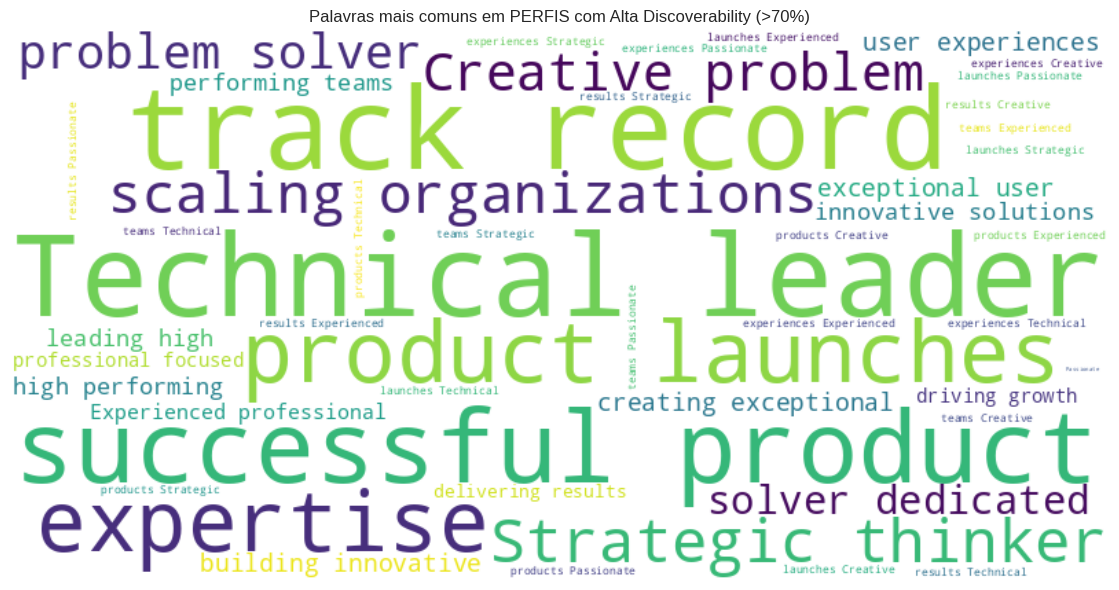

In [12]:
# =============================================================================
# EDA ESSENCIAL
# Objetivo: Entender o que influencia a discoverability (0-100) de perfis e posts
# =============================================================================

# Configuração visual (bonito e profissional para relatório)
plt.style.use('seaborn-v0_8')
sns.set_palette("Blues_d")
%matplotlib inline

# ------------------------------------------------------------------
# 1. Resumo dos Targets (o que realmente vamos prever)
# ------------------------------------------------------------------
print("=== RESUMO DOS TARGETS DE DISCOVERABILITY ===")
print(df_profiles[["profile_discoverability_score"]].describe().round(2))
print("\n")
print(df_influencers[["post_discoverability_score"]].describe().round(2))

# ------------------------------------------------------------------
# 2. Distribuição dos Targets (cada gráfico em uma linha)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 5))
sns.histplot(df_profiles["profile_discoverability_score"], bins=50, kde=True)
plt.title("Distribuição - Discoverability de Perfis (0-100)")
plt.xlabel("Score de Discoverability")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df_influencers["post_discoverability_score"], bins=50, kde=True)
plt.title("Distribuição - Discoverability de Posts (0-100)")
plt.xlabel("Score de Discoverability")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. Matriz de Correlação (apenas variáveis mais relevantes)
# ------------------------------------------------------------------
# Selecionamos as features mais importantes + os dois targets
cols_corr = [
    "profile_discoverability_score", "num_skills", "num_experience",
    "num_education", "about_length", "headline_length", "connections",
    "years_experience", "seniority_level"
]

# Para posts
cols_corr_posts = [
    "post_discoverability_score", "num_hashtags", "reactions", "comments",
    "followers", "engagement_per_day_clipped", "media_type"
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_profiles[cols_corr].corr(numeric_only=True),
    annot=True, cmap="Blues", fmt=".2f", linewidths=0.5
)
plt.title("Correlação - Discoverability de Perfis")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4. Insights por Grupo (cada gráfico em uma linha)
# ------------------------------------------------------------------
# 4.1 Discoverability por Seniority
plt.figure(figsize=(12, 5))
sns.barplot(data=df_profiles, x="seniority_level", y="profile_discoverability_score")
plt.title("Discoverability média por Seniority Level")
plt.ylabel("Score médio")
plt.xlabel("Seniority Level")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 4.2 Discoverability por Industry (top 8)
top_ind = df_profiles.groupby("industry")["profile_discoverability_score"].mean().nlargest(8)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_ind.values, y=top_ind.index)
plt.title("Top 8 Indústrias com maior Discoverability")
plt.xlabel("Score médio")
plt.ylabel("Indústria")
plt.tight_layout()
plt.show()

# 4.3 Discoverability de Posts por Tipo de Mídia
plt.figure(figsize=(12, 5))
sns.barplot(data=df_influencers, x="media_type", y="post_discoverability_score")
plt.title("Discoverability média por Tipo de Mídia")
plt.xlabel("Tipo de Mídia")
plt.ylabel("Score médio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 4.4 Discoverability de Posts por Número de Hashtags
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_influencers,
    x=pd.cut(df_influencers["num_hashtags"], bins=[0, 1, 3, 6, 10, 50]),
    y="post_discoverability_score"
 )
plt.title("Discoverability por Quantidade de Hashtags")
plt.xlabel("Número de Hashtags")
plt.ylabel("Score de Discoverability")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Word Clouds (o que as pessoas escrevem nos posts/perfis mais descobríveis)
# ------------------------------------------------------------------
# Posts com alta discoverability (> 70)
high_post = df_influencers[df_influencers["post_discoverability_score"] > 70]["content"].str.cat(sep=" ")

wordcloud_post = WordCloud(width=800, height=400, background_color="white", max_words=100).generate(high_post)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_post, interpolation="bilinear")
plt.axis("off")
plt.title("Palavras mais comuns em POSTS com Alta Discoverability (>70%)")
plt.tight_layout()
plt.show()

# Perfis com alta discoverability (> 70)
high_profile = df_profiles[df_profiles["profile_discoverability_score"] > 70]["about"].str.cat(sep=" ")
wordcloud_profile = WordCloud(width=800, height=400, background_color="white", max_words=80).generate(high_profile)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_profile, interpolation="bilinear")
plt.axis("off")
plt.title("Palavras mais comuns em PERFIS com Alta Discoverability (>70%)")
plt.tight_layout()
plt.show()